# PCA Dislocation on Swap Spreads (MMSS / Spreadover)

Applies the PCA dislocation framework directly to swap spread **changes**:

1. Run rolling PCA on daily spread changes across the benchmark tenor panel (2Y–30Y)
2. Reconstruct each tenor's 'fair' spread change from the top-k PCs
3. Cumulate the out-of-sample residuals (the idiosyncratic component)
4. Model cumulative residuals as an OU process → z-score
5. Trade dislocations via outright swap spread trades (bond + matched-maturity swap per leg)

**Spread convention:** spread = swap rate − treasury yield (negative in US).
- **Buy spread (pay spread):** buy bonds + pay fixed swaps → profit when spread goes UP (narrows, less negative)
- **Sell spread (receive spread):** sell bonds + receive fixed swaps → profit when spread goes DOWN (widens, more negative)

**MMSS vs Spreadover:** When `use_mmss=True`, the swap leg tenor is set to `CT{N}` which matches the swap maturity to the OTR bond maturity. When `False`, uses headline `{N}Y` tenor.

In [95]:
%load_ext autoreload
%autoreload 2

import datetime, sys, os, time, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import QuantLib as ql

plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'x-large', 'figure.figsize': (18, 8),
    'axes.labelsize': 'x-large', 'axes.titlesize': 'x-large',
    'xtick.labelsize': 'large', 'ytick.labelsize': 'large',
})

sys.path.append('../../')

from BT.data_handler import TimeGrid
from BT.misc import ql_cal_date_range
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from BT.query_tearsheet import QueryBacktestTearSheet

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.signals.tfp_swap_spread import (
    BENCHMARK_TENORS, REGRESSION_TENORS, CT_MAP, build_tfp_history,
)
from BT.signals.irswap_pca_rv_scanner import IRSwapPCARVConfig, _rolling_pca_surface
from BT.signals.tfp_packages import _ou_params
from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [96]:
cfg = dict(
    signal_start    = datetime.date(2020, 6, 1),
    bt_start        = datetime.date(2021, 6, 1),
    bt_end          = datetime.date(2026, 5, 14),

    # PCA
    pca_window      = 180,       
    # pca_input       = 'changes', # PCA on daily spread changes (not levels)
    pca_input       = 'levels',
    n_components    = 3,         # top 3 PCs (level/slope/curvature)

    # Z-score on cumulative residuals
    zscore_window   = 60,
    z_entry         = 1.25,       # entry threshold
    z_exit          = 0.125,      # exit near zero (mean-reversion target)
    max_hold        = 20,        # max holding period

    # Trade universe
    tenors          = ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'],

    # Spread type: True = matched-maturity (CT prefix), False = headline spreadover
    use_mmss        = True,

    # Risk
    risk_bpv        = 250_000,
    unwind_fee_bps  = 1.0,
    specialness_bps = 10.0,

    # Data
    irs_source      = 'ERIS_EOD_LIVE-RL_BASIC',
    frb_source      = 'USTS_FEDINVEST_WSJ_LIVE-QL',
    cache_path      = os.path.abspath(os.path.join(
        os.getcwd(), '..', '..', 'BT', 'results', 'tfp_screener', 'tfp_history.parquet'
    )),
)

for k, v in cfg.items():
    print(f'  {k}: {v}')

  signal_start: 2020-06-01
  bt_start: 2021-06-01
  bt_end: 2026-05-14
  pca_window: 180
  pca_input: levels
  n_components: 3
  zscore_window: 60
  z_entry: 1.25
  z_exit: 0.125
  max_hold: 20
  tenors: ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
  use_mmss: True
  risk_bpv: 250000
  unwind_fee_bps: 1.0
  specialness_bps: 10.0
  irs_source: ERIS_EOD_LIVE-RL_BASIC
  frb_source: USTS_FEDINVEST_WSJ_LIVE-QL
  cache_path: c:\Users\chris\clee\ARBS\BT\results\tfp_screener\tfp_history.parquet


## Load MMSS Panel

In [97]:
curve_mdp = IRSwapsMDP(source=cfg['irs_source'])
usts_mdp = FixedRateBondsMDP(source='USTS_FEDINVEST_WSJ_LIVE-RL')

history = build_tfp_history(
    start_date=cfg['signal_start'], end_date=cfg['bt_end'],
    curve_mdp=curve_mdp, usts_mdp=usts_mdp,
    cache_path=cfg['cache_path'], show_progress=True,
)
history = history.loc[cfg['signal_start']:cfg['bt_end']]

# Build MMSS panel: (date x tenor) from the cached TFP history
mmss_panel = pd.DataFrame({
    t: history[f'mmss_{t}'] for t in cfg['tenors'] if f'mmss_{t}' in history.columns
}).dropna()

print(f'MMSS panel: {mmss_panel.shape[0]} dates x {mmss_panel.shape[1]} tenors')
print(f'Tenors: {mmss_panel.columns.tolist()}')
print(f'Range: {mmss_panel.index.min()} to {mmss_panel.index.max()}')
mmss_panel.tail()

MMSS panel: 1475 dates x 7 tenors
Tenors: ['2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Range: 2020-06-22 00:00:00 to 2026-05-14 00:00:00


,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,
2026-05-08,-16.704807,-20.820668,-28.513365,-35.191996,-41.404614,-67.133446,-71.652659
2026-05-11,-18.908454,-23.800253,-30.265469,-37.939666,-43.262718,-70.589922,-73.676693
2026-05-12,-16.915295,-20.919930,-28.263889,-36.921184,-41.864600,-70.223320,-73.023950
2026-05-13,-16.060925,-21.385833,-28.735127,-37.211077,-43.235861,-71.899343,-74.950783
2026-05-14,-17.256295,-21.987016,-28.745907,-36.778102,-41.789877,-70.238623,-73.329002


## Rolling PCA → Residuals → Z-scores

Uses the production `_rolling_pca_surface` engine from `irswap_pca_rv_scanner.py`.

In [98]:
pca_cfg = IRSwapPCARVConfig(
    pca_window_days=cfg['pca_window'],
    pca_input=cfg['pca_input'],
    n_components=cfg['n_components'],
    zscore_lookback_days=cfg['zscore_window'],
)

t0 = time.time()
residuals, zscores, var_exp, loadings_dict, reconstructed = _rolling_pca_surface(
    mmss_panel, pca_cfg,
)
print(f'PCA scan: {time.time()-t0:.1f}s')
print(f'Residuals non-NaN: {residuals.notna().sum().to_dict()}')
print(f'Z-scores non-NaN:  {zscores.notna().sum().to_dict()}')

# Variance explained by top 3 PCs
ve_recent = var_exp.dropna().tail(60)
if not ve_recent.empty:
    print(f'\nVariance explained (last 60d avg): {ve_recent.mean().to_dict()}')

PCA scan: 2.0s
Residuals non-NaN: {'2Y': 1295, '3Y': 1295, '5Y': 1295, '7Y': 1295, '10Y': 1295, '20Y': 1295, '30Y': 1295}
Z-scores non-NaN:  {'2Y': 1235, '3Y': 1235, '5Y': 1235, '7Y': 1235, '10Y': 1235, '20Y': 1235, '30Y': 1235}

Variance explained (last 60d avg): {'PC1': 0.9364304836052894, 'PC2': 0.05325675579626754, 'PC3': 0.005179858221366827}


## Cumulative Residuals + OU Analytics

In [99]:
# Cumulate residuals — the OU process lives on the cumulated series
cum_residuals = residuals.cumsum()

# OU diagnostics per tenor
print(f'{"Tenor":>6s}  {"OU mu":>8s}  {"OU HL":>7s}  {"OU theta":>9s}  {"OU sigma":>9s}')
print('-' * 50)
for t in cfg['tenors']:
    if t not in cum_residuals.columns:
        continue
    s = cum_residuals[t].dropna()
    if len(s) < 100:
        continue
    ou = _ou_params(s.iloc[-cfg['pca_window']:])
    print(f'{t:>6s}  {ou["mu"]:>8.2f}  {ou["half_life"]:>7.0f}d  {ou["theta"]:>9.3f}  {ou["sigma"]:>9.3f}')

 Tenor     OU mu    OU HL   OU theta   OU sigma
--------------------------------------------------
    2Y       nan      nand        nan        nan
    3Y     62.26       52d      0.013      0.438
    5Y    167.14      447d      0.002      0.433
    7Y       nan      nand        nan        nan
   10Y       nan      nand        nan        nan
   20Y   -178.18      424d      0.002      0.413
   30Y    892.46     1727d      0.000      0.416


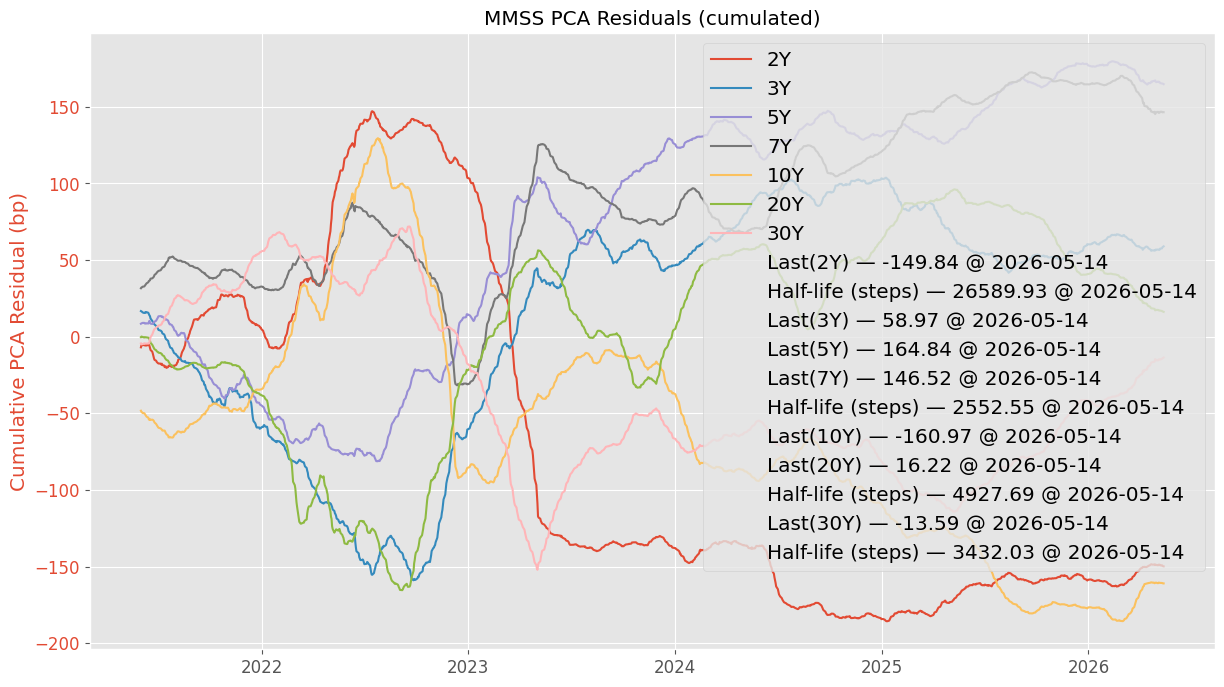

In [100]:
# Plot cumulative residuals
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative PCA Residual (bp)', title='MMSS PCA Residuals (cumulated)',
)
for t in cfg['tenors']:
    if t in cum_residuals.columns:
        s = cum_residuals[t].loc[cfg['bt_start']:cfg['bt_end']]
        plot(s.rename(t), which='left', indicators=[
            {'kind': 'last', 'hide': True},
            {'kind': 'half_life', 'hide': True},
        ])
legend(show_date=True)
plt.show()

## Z-score Surface & Signal Generation

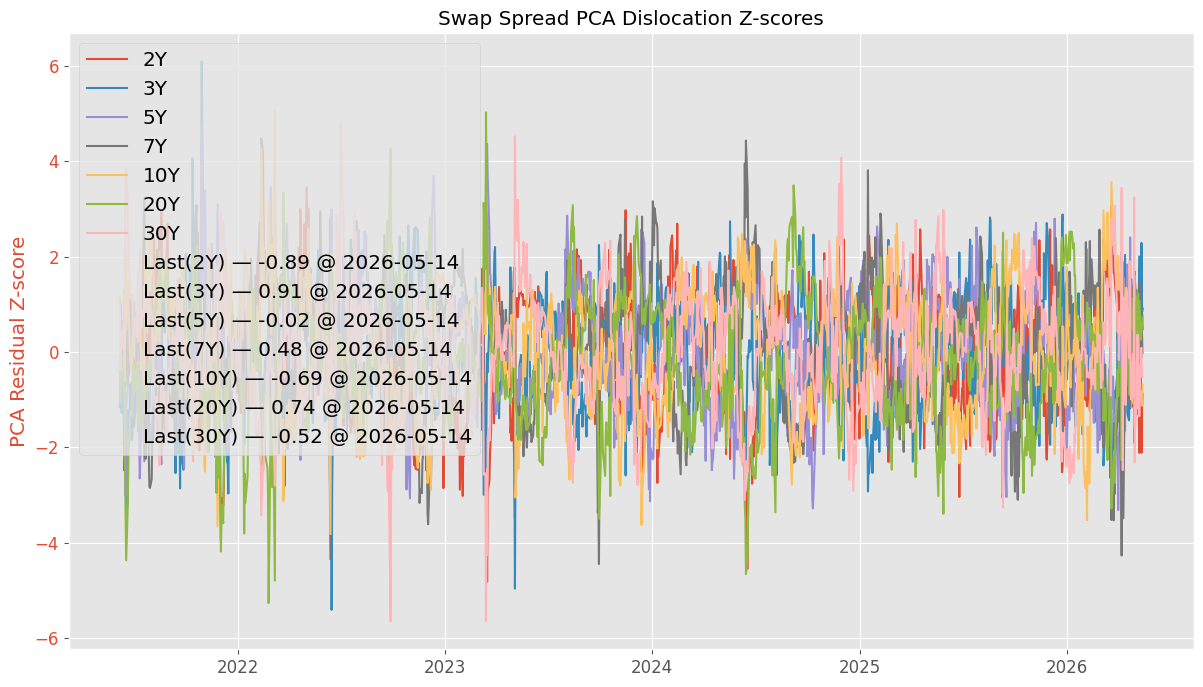

Current PCA dislocation z-scores:
  spread = swap rate - treasury yield
  z < 0 → spread cheap (below PCA fair value) → buy spread (buy bonds + pay swaps)
  z > 0 → spread rich  (above PCA fair value) → sell spread (sell bonds + receive swaps)

    2Y: z = -0.89  neutral
    3Y: z = +0.91  neutral
    5Y: z = -0.02  neutral
    7Y: z = +0.48  neutral
   10Y: z = -0.69  neutral
   20Y: z = +0.74  neutral
   30Y: z = -0.52  neutral


In [101]:
# Plot z-score surface
z_bt = zscores.loc[cfg['bt_start']:cfg['bt_end']]

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='PCA Residual Z-score', title='Swap Spread PCA Dislocation Z-scores',
)
for t in cfg['tenors']:
    if t in z_bt.columns:
        plot(z_bt[t].rename(t), which='left', indicators=[{'kind': 'last', 'hide': True}])
legend(show_date=True)
plt.show()

# Current snapshot
latest_z = zscores.dropna(how='all').iloc[-1]
print('Current PCA dislocation z-scores:')
print('  spread = swap rate - treasury yield')
print('  z < 0 → spread cheap (below PCA fair value) → buy spread (buy bonds + pay swaps)')
print('  z > 0 → spread rich  (above PCA fair value) → sell spread (sell bonds + receive swaps)')
print()
for t in cfg['tenors']:
    if t in latest_z.index and pd.notna(latest_z[t]):
        z_val = latest_z[t]
        if z_val < -cfg['z_entry']:
            tag = 'CHEAP → BUY SPREAD (buy bonds + pay swaps)'
        elif z_val > cfg['z_entry']:
            tag = 'RICH → SELL SPREAD (sell bonds + receive swaps)'
        else:
            tag = 'neutral'
        print(f'  {t:>4s}: z = {z_val:+.2f}  {tag}')

In [102]:
# Generate entry/exit signals per tenor
# Signal convention:
#   +1 = BUY SPREAD (buy bonds + pay swaps) → want spread to go UP (less negative)
#        triggered when z < -z_entry (spread is cheap vs PCA fair value)
#   -1 = SELL SPREAD (sell bonds + receive swaps) → want spread to go DOWN (more negative)
#        triggered when z > +z_entry (spread is rich vs PCA fair value)

def generate_pca_signals(zscores, z_entry, z_exit, max_hold):
    signals = pd.DataFrame(0, index=zscores.index, columns=zscores.columns, dtype=np.int8)
    for t in zscores.columns:
        z = zscores[t].values
        sig = np.zeros(len(z), dtype=np.int8)
        pos = 0; hold = 0
        for i in range(len(z)):
            v = z[i]
            if np.isnan(v):
                sig[i] = 0; pos = 0; hold = 0; continue
            if pos == 0:
                if v < -z_entry:   pos = +1; hold = 0  # cheap → buy spread
                elif v > z_entry:  pos = -1; hold = 0  # rich  → sell spread
            else:
                hold += 1
                exit_now = hold >= max_hold
                if not exit_now:
                    if pos == +1 and v >= -z_exit: exit_now = True   # bought spread, z reverted up
                    elif pos == -1 and v <= z_exit: exit_now = True  # sold spread, z reverted down
                if exit_now: pos = 0; hold = 0
            sig[i] = pos
        signals[t] = sig
    return signals

pca_signals = generate_pca_signals(zscores, cfg['z_entry'], cfg['z_exit'], cfg['max_hold'])

for t in cfg['tenors']:
    if t in pca_signals.columns:
        sig_bt = pca_signals[t].loc[cfg['bt_start']:cfg['bt_end']]
        n_buy = ((sig_bt == 1) & (sig_bt.shift(1).fillna(0) != 1)).sum()
        n_sell = ((sig_bt == -1) & (sig_bt.shift(1).fillna(0) != -1)).sum()
        print(f'  {t}: {n_buy + n_sell} trades ({n_buy} buy spread, {n_sell} sell spread)')

  2Y: 96 trades (49 buy spread, 47 sell spread)
  3Y: 107 trades (56 buy spread, 51 sell spread)
  5Y: 91 trades (46 buy spread, 45 sell spread)
  7Y: 80 trades (36 buy spread, 44 sell spread)
  10Y: 78 trades (35 buy spread, 43 sell spread)
  20Y: 62 trades (36 buy spread, 26 sell spread)
  30Y: 74 trades (33 buy spread, 41 sell spread)


## Vectorized P&L Preview (fast screening before full QDB)

In [103]:
h_bt = mmss_panel.loc[cfg['bt_start']:cfg['bt_end']]
preview = []
equity_curves = {}

for t in cfg['tenors']:
    if t not in pca_signals.columns or t not in h_bt.columns:
        continue
    sig = pca_signals[t].loc[cfg['bt_start']:cfg['bt_end']].reindex(h_bt.index).fillna(0)
    # sig=+1 (buy spread) profits when spread goes UP (MMSS increases / less negative)
    # sig=-1 (sell spread) profits when spread goes DOWN (MMSS decreases / more negative)
    # P&L = signal × Δ(spread)
    daily = sig.shift(1) * h_bt[t].diff()
    daily = daily.fillna(0)
    cum = daily.cumsum()
    equity_curves[t] = cum

    sh = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
    mdd = (cum - cum.cummax()).min()
    n_trades = ((sig != 0) & (sig.shift(1).fillna(0) == 0)).sum()
    
    cr = cum_residuals[t].loc[cfg['bt_start']:cfg['bt_end']].dropna()
    ou = _ou_params(cr) if len(cr) > 60 else {'half_life': np.nan}

    preview.append(dict(
        Tenor=t, Sharpe=round(sh, 3), Total_bp=round(cum.iloc[-1], 1),
        MaxDD_bp=round(mdd, 1), Trades=int(n_trades),
        OU_HL=round(ou['half_life'], 0) if np.isfinite(ou.get('half_life', np.nan)) else np.nan,
    ))

preview_df = pd.DataFrame(preview).sort_values('Sharpe', ascending=False)
preview_df

,Tenor,Sharpe,Total_bp,MaxDD_bp,Trades,OU_HL
2,5Y,1.589,133.5,-15.8,91,NaN
0,2Y,1.221,123.5,-19.7,96,26590.0
6,30Y,0.657,66.3,-37.6,74,3432.0
1,3Y,0.619,53.1,-56.9,107,NaN
3,7Y,0.479,44.2,-22.3,80,2553.0
4,10Y,0.345,31.3,-21.3,78,NaN
5,20Y,-0.227,-24.6,-69.3,62,4928.0


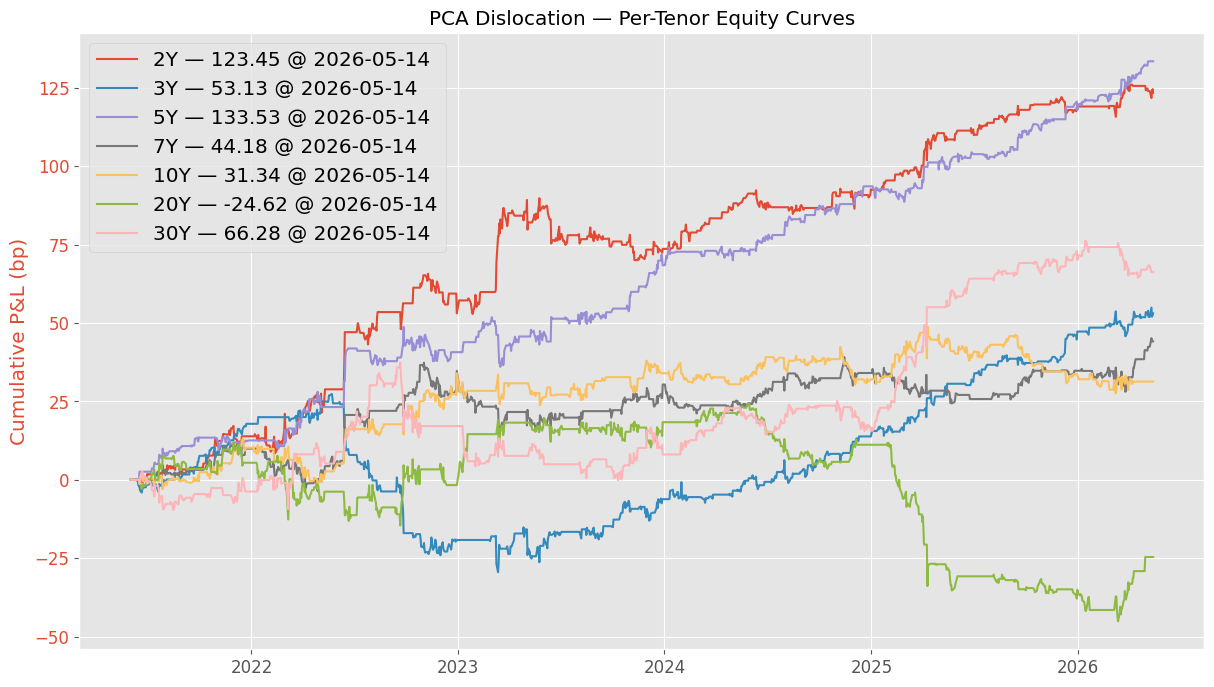

In [104]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative P&L (bp)', title='PCA Dislocation — Per-Tenor Equity Curves',
)
for t, eq in equity_curves.items():
    # plot(eq.rename(t), which='left', indicators=[{'kind': 'last', 'hide': True}])
    plot(eq.rename(t), which='left')
legend(show_date=True)
plt.show()

## Extract Entry/Exit Events

In [105]:
# Convert PCA signals → entry/exit events with datetime.date (required by DateTriggerRequirements)
TRADE_TENORS = preview_df[preview_df['Sharpe'] > 0]['Tenor'].tolist()
print(f'Trading tenors (Sharpe > 0): {TRADE_TENORS}')

def extract_pca_events(sig_series, tenor, bt_start, bt_end):
    sig = sig_series.loc[bt_start:bt_end]
    dates = [d.date() if hasattr(d, 'date') else d for d in sig.index]
    vals = sig.values
    events = []
    prev = 0; entry_date = None; direction = 0
    for i in range(len(vals)):
        cur = int(vals[i])
        if prev == 0 and cur != 0:
            entry_date = dates[i]; direction = cur
        elif prev != 0 and cur == 0:
            events.append(dict(
                entry_date=entry_date, exit_date=dates[i],
                direction=direction, tenor=tenor,
                tag=f'pca-{tenor}-{entry_date}',
            ))
            entry_date = None; direction = 0
        elif prev != 0 and cur != 0 and cur != prev:
            events.append(dict(
                entry_date=entry_date, exit_date=dates[i],
                direction=direction, tenor=tenor,
                tag=f'pca-{tenor}-{entry_date}',
            ))
            entry_date = dates[i]; direction = cur
        prev = cur
    if entry_date is not None:
        events.append(dict(
            entry_date=entry_date, exit_date=dates[-1],
            direction=direction, tenor=tenor,
            tag=f'pca-{tenor}-{entry_date}',
        ))
    return events

all_events = []
for tenor in TRADE_TENORS:
    if tenor not in pca_signals.columns:
        continue
    evts = extract_pca_events(pca_signals[tenor], tenor, cfg['bt_start'], cfg['bt_end'])
    all_events.extend(evts)
    n_buy  = sum(1 for e in evts if e['direction'] == +1)
    n_sell = sum(1 for e in evts if e['direction'] == -1)
    print(f'  {tenor}: {len(evts)} trades ({n_buy} buy spread, {n_sell} sell spread)')
print(f'Total: {len(all_events)} trades')

Trading tenors (Sharpe > 0): ['5Y', '2Y', '30Y', '3Y', '7Y', '10Y']
  5Y: 91 trades (46 buy spread, 45 sell spread)
  2Y: 96 trades (49 buy spread, 47 sell spread)
  30Y: 74 trades (33 buy spread, 41 sell spread)
  3Y: 107 trades (56 buy spread, 51 sell spread)
  7Y: 80 trades (36 buy spread, 44 sell spread)
  10Y: 78 trades (35 buy spread, 43 sell spread)
Total: 526 trades


In [ ]:
# ── Initialize MDPs & Financing ──
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
tg = TimeGrid(ql_cal_date_range(ql_cal=CAL, start=cfg['bt_start'], end=cfg['bt_end']))

gc_fixing_pct = pd.Series(
    {d: load_us_treasury_gc_fixing_pct(d) for d in sorted({ts.date() for ts in tg})},
    dtype=float,
).sort_index().ffill().bfill()
print(f'GC fixing range: {gc_fixing_pct.min():.2f}% to {gc_fixing_pct.max():.2f}%')

financing_config = {
    'mode': 'gc_plus_specialness',
              'gc_rate': gc_fixing_pct / 100.0,
    'leg_specialness_bps': {'outright': cfg['specialness_bps']},
    'day_count': 'ACT/360',
    'haircut': 0.0,
}

frb_mdp = FixedRateBondsMDP(source=cfg['frb_source'])
irs_mdp = IRSwapsMDP(source=cfg['irs_source'])

GC fixing range: 0.01% to 5.40%


## Build Triggers & Run QueryDrivenBacktest

Each outright swap spread trade = 2 legs:
- **Bond leg**: `FixedRateBondQuery` with CT alias, financed at GC repo + specialness
- **Swap leg**: `IRSwapQuery` — when `use_mmss=True`, tenor is `CT{N}` (matched maturity); when `False`, tenor is `{N}Y` (headline spreadover)

Direction mapping:
- `direction=+1` (buy spread): bond_bpv > 0 (buy bonds) + swap_bpv < 0 (pay fixed swaps)
- `direction=-1` (sell spread): bond_bpv < 0 (sell bonds) + swap_bpv > 0 (receive fixed swaps)

In [107]:
# ── Build triggers ──
triggers = []
for ev in all_events:
    tenor = ev['tenor']
    direction = ev['direction']   # +1 = buy spread (buy bonds + pay swaps)
                                  # -1 = sell spread (sell bonds + receive swaps)
    tag = ev['tag']
    ct = CT_MAP[tenor]            # e.g. 'CT10' for '10Y'

    # Bond leg: direction > 0 → buy bonds (long), direction < 0 → sell bonds (short)
    bond_bpv = cfg['risk_bpv'] * direction
    # Swap leg: opposite sign for duration neutrality
    # direction > 0 → pay fixed (negative BPV), direction < 0 → receive fixed (positive BPV)
    swap_bpv = -cfg['risk_bpv'] * direction

    bond_query = FixedRateBondQuery(
        cusip=ct,
        value=FixedRateBondValue.NPV,
        structure_kwargs={'bpv': bond_bpv},
        meta={'financing': financing_config},
        tags=(tag,),
    )

    # Swap tenor: CT prefix for MMSS (matched maturity), plain tenor for spreadover
    swap_tenor = ct if cfg['use_mmss'] else tenor
    swap_query = IRSwapQuery(
        curve='USD-SOFR-1D',
        tenor=swap_tenor,
        value=IRSwapValue.NPV,
        structure_kwargs={'bpv': swap_bpv},
        tags=(tag,),
    )

    triggers.append(DateTrigger(
        DateTriggerRequirements(dates=[ev['entry_date']]),
        actions=[AddQueryAction(query=bond_query), AddQueryAction(query=swap_query)],
    ))
    triggers.append(DateTrigger(
        DateTriggerRequirements(dates=[ev['exit_date']]),
        actions=[UnwindPositionsAction(match_tag=tag, fee=cfg['unwind_fee_bps'] * cfg['risk_bpv'])],
    ))

spread_type = 'MMSS (matched maturity)' if cfg['use_mmss'] else 'Spreadover (headline)'
print(f'Spread type: {spread_type}')
print(f'Built {len(triggers)} triggers ({len(all_events)} trades x 2)')

# ── Run ──
strategy = QueryStrategy(
    name=f"PCA {'MMSS' if cfg['use_mmss'] else 'Spreadover'} Dislocation ({', '.join(TRADE_TENORS)})",
    triggers=triggers,
    mdps={'FRB': frb_mdp, 'IRS': irs_mdp},
)

bt = QueryDrivenBacktest(time_grid=tg, strategy=strategy)
t0 = time.time()
bt.run()
print(f'Elapsed: {time.time()-t0:.0f}s')

Spread type: MMSS (matched maturity)
Built 1052 triggers (526 trades x 2)


BACKTESTING...:  18%|█▊        | 221/1239 [03:14<20:44,  1.22s/step]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2022-04-15 00:00:00')] not in index"


BACKTESTING...:  38%|███▊      | 465/1239 [08:07<12:00,  1.07step/s]

The supplied `fixings` contain more fixings than were expected by the holiday calendar of the `curve`.
The additional fixing dates are shown in the underlying KeyError message below.
If the Series you are providing contains valid fixings the fault probably lies with Rateslib calendar definitions and should be reported.
This error can avoided by excluding these fixings using Series.pop().
"[Timestamp('2023-04-07 00:00:00')] not in index"


...

"Missing FRB pricer for leg cusip='CT2'. available=[]"


WARNING	Task(Task-2) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- Failed to fetch pricer for CT2 @ 2026-05-13: asyncio.run() cannot be called from a running event loop
c:\Users\chris\clee\ARBS\notebooks\backtests\../..\MDP\FixedRateBonds\FixedRateBondsMDP.py:983: RuntimeWarning:

coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited

WARNING	Task(Task-2) MDP.FixedRateBonds.FixedRateBondsMDP:FixedRateBondsMDP.py:_get_multi_pricers()- Failed to fetch pricer for 91282CQL8 @ 2026-05-13: asyncio.run() cannot be called from a running event loop
c:\Users\chris\clee\ARBS\notebooks\backtests\../..\MDP\FixedRateBonds\FixedRateBondsMDP.py:983: RuntimeWarning:

coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited

BACKTESTING...: 100%|█████████▉| 1237/1239 [25:52<00:02,  1.21s/step]c:\Users\chris\clee\ARBS\notebooks\backtests\../..\BT\query_engine.py:354: RuntimeWarning:

coroutine 'WSJFetcher.u

"Missing FRB pricer for leg cusip='CT2'. available=[]"
asyncio.run() cannot be called from a running event loop


c:\Users\chris\clee\ARBS\notebooks\backtests\../..\BT\query_engine.py:354: RuntimeWarning:

coroutine 'WSJFetcher.ust_intraday_timeseries.<locals>.run_fetch_all' was never awaited

BACKTESTING...: 100%|██████████| 1239/1239 [25:52<00:00,  1.25s/step]

asyncio.run() cannot be called from a running event loop
Elapsed: 1553s


## Results

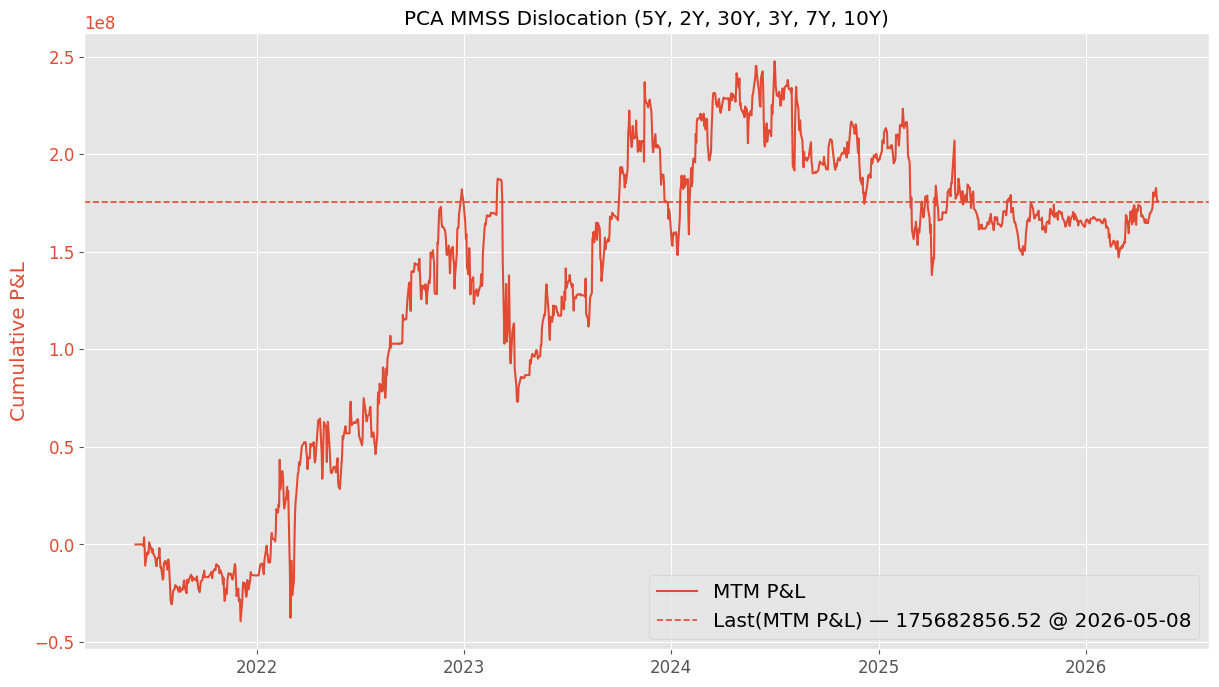

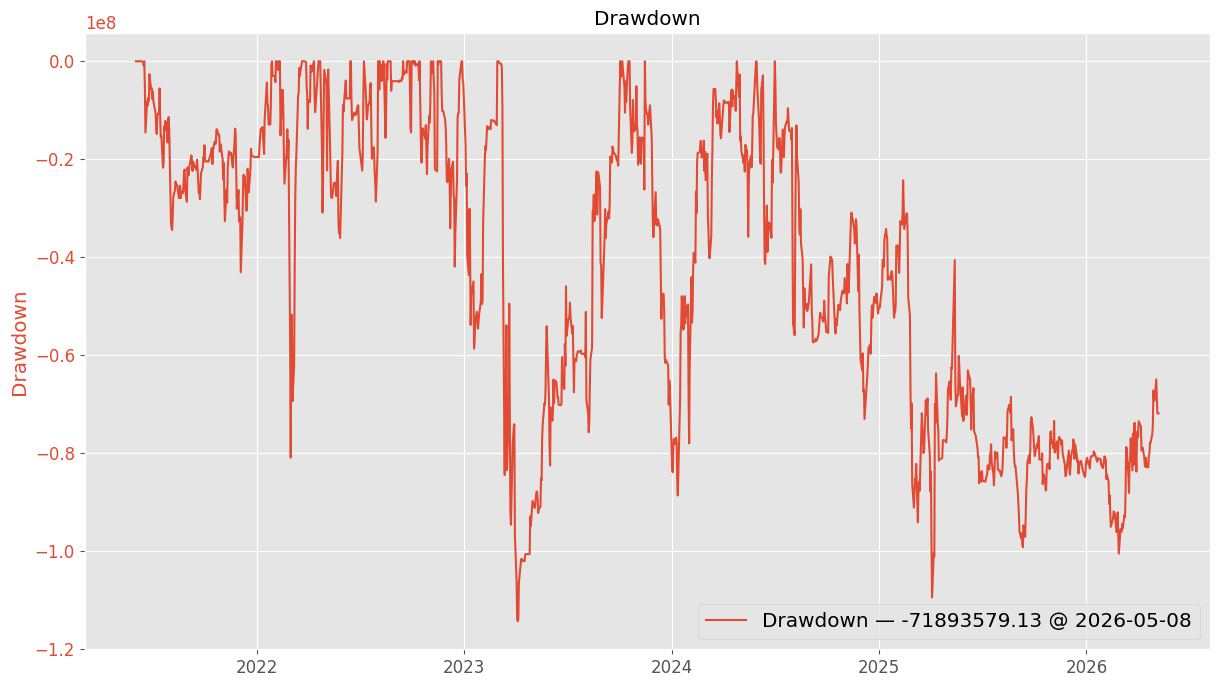

Tenors:       ['5Y', '2Y', '30Y', '3Y', '7Y', '10Y']
Signal:       z_entry=1.25, z_exit=0.125, max_hold=20
PCA:          3 PCs, window=180, input=levels
Risk BPV:     250,000

Final MTM:     175,682,857
Peak:          247,576,436
Max DD:       -114,340,525
Sharpe:               0.35
Daily vol:       6,459,722


In [108]:
mtm = pd.Series(bt.mtm_history).sort_index()
daily_pnl = mtm.diff().dropna()

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Cumulative P&L', title=strategy.name,
)
plot(mtm.rename('MTM P&L'), which='left', indicators=[
    {'kind': 'last', 'style': {'linestyle': '--', 'linewidth': 1.2}},
])
legend(show_date=True)
plt.show()

# Drawdown
dd = mtm - mtm.cummax()
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    ylabel_left='Drawdown', title='Drawdown',
)
plot(dd.rename('Drawdown'), which='left')
legend(show_date=True)
plt.show()

sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
max_dd = dd.min()

print(f'Tenors:       {TRADE_TENORS}')
print(f'Signal:       z_entry={cfg["z_entry"]}, z_exit={cfg["z_exit"]}, max_hold={cfg["max_hold"]}')
print(f'PCA:          {cfg["n_components"]} PCs, window={cfg["pca_window"]}, input={cfg["pca_input"]}')
print(f'Risk BPV:     {cfg["risk_bpv"]:,}')
print(f'\nFinal MTM:    {mtm.iloc[-1]:>12,.0f}')
print(f'Peak:         {mtm.max():>12,.0f}')
print(f'Max DD:       {max_dd:>12,.0f}')
print(f'Sharpe:       {sharpe:>12.2f}')
print(f'Daily vol:    {daily_pnl.std():>12,.0f}')

## Closed Trades Analysis

Per-trade P&L aggregated by tag (bond + swap legs summed). Tags extracted from `source_query.tags`.

In [109]:
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if not closed.empty:
    def _extract_tag(row):
        sq = row.get('source_query', None)
        if sq is not None and hasattr(sq, 'tags') and sq.tags:
            return sq.tags[0]
        pos = row.get('position', None)
        if pos is not None and hasattr(pos, 'source_query'):
            sq2 = pos.source_query
            if hasattr(sq2, 'tags') and sq2.tags:
                return sq2.tags[0]
        return None

    closed['tag'] = closed.apply(_extract_tag, axis=1)
    trade_pnl = closed.dropna(subset=['tag']).groupby('tag').agg(
        realized_pnl=('realized_pnl', 'sum'),
        holding_days=('holding_period_days', 'mean'),
        opened=('opened_at', 'min'),
        closed=('closed_at', 'max'),
    ).sort_values('opened')

    trade_pnl['tenor'] = trade_pnl.index.str.extract(r'pca-(\w+)-')[0].values

    n_trades = len(trade_pnl)
    n_winners = (trade_pnl['realized_pnl'] > 0).sum()
    avg_win = trade_pnl.loc[trade_pnl['realized_pnl'] > 0, 'realized_pnl'].mean()
    avg_loss = trade_pnl.loc[trade_pnl['realized_pnl'] <= 0, 'realized_pnl'].mean()

    print(f'Trades: {n_trades}')
    print(f'Winners: {n_winners} ({n_winners/n_trades:.0%})')
    if pd.notna(avg_win): print(f'Avg win:  {avg_win:,.0f}')
    if pd.notna(avg_loss): print(f'Avg loss: {avg_loss:,.0f}')
    print(f'Avg holding: {trade_pnl["holding_days"].mean():.0f} days')
    print(f'Total P&L: {trade_pnl["realized_pnl"].sum():,.0f}')
    print()

    tenor_summary = trade_pnl.groupby('tenor').agg(
        n_trades=('realized_pnl', 'count'),
        total_pnl=('realized_pnl', 'sum'),
        avg_pnl=('realized_pnl', 'mean'),
        hit_rate=('realized_pnl', lambda x: (x > 0).mean()),
        avg_days=('holding_days', 'mean'),
    )
    display(tenor_summary)
else:
    print('No closed trades.')

Trades: 523
Winners: 295 (56%)
Avg win:  4,174,987
Avg loss: -4,598,866
Avg holding: 10 days
Total P&L: 183,079,705



,n_trades,total_pnl,avg_pnl,hit_rate,avg_days
tenor,,,,,
10Y,78,1.335782e+06,17125.412154,0.512821,12.641026
2Y,95,-1.715765e+07,-180606.842020,0.600000,8.989474
30Y,74,1.053477e+07,142361.750341,0.513514,12.027027
3Y,105,3.794964e+07,361425.178852,0.542857,8.200000
5Y,91,7.942226e+07,872772.050584,0.626374,10.076923
7Y,80,7.099490e+07,887436.290312,0.575000,12.225000


## Financing Decomposition

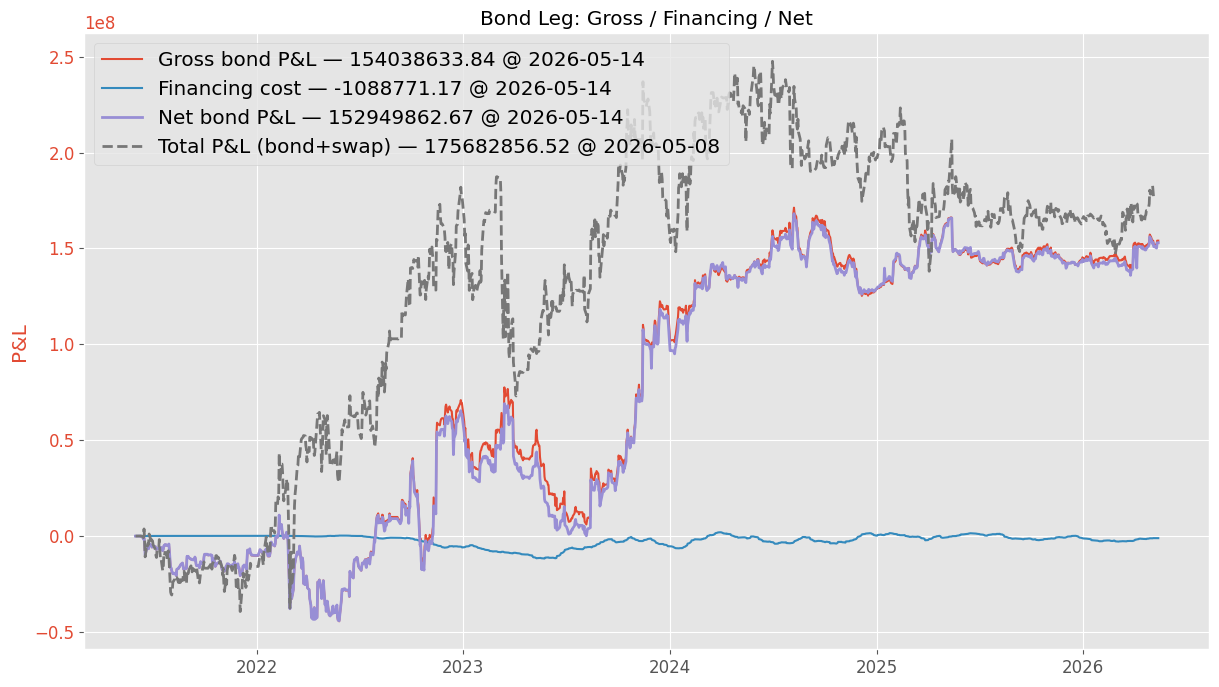

In [110]:
component_histories = getattr(bt, 'frb_component_histories', {})

if component_histories:
    time_index = pd.Index(list(tg), name='date')
    gross_bond = pd.Series(component_histories.get('bond_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)
    financing = pd.Series(component_histories.get('financing_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)
    net = pd.Series(component_histories.get('net_total', {}), dtype=float
        ).sort_index().reindex(time_index).ffill().fillna(0.0)

    plot, fig, ax, ax2, legend = make_secondary_axis_plot(
        ylabel_left='P&L', title='Bond Leg: Gross / Financing / Net',
    )
    plot(gross_bond.rename('Gross bond P&L'), which='left')
    plot(financing.rename('Financing cost'), which='left')
    plot(net.rename('Net bond P&L'), which='left', linewidth=2)
    plot(mtm.rename('Total P&L (bond+swap)'), which='left', linewidth=2, linestyle='--')
    legend(show_date=True)
    plt.show()
else:
    print('No FRB component history available.')

## Tearsheet

In [111]:
try:
    tearsheet = QueryBacktestTearSheet.from_backtest(bt)
    plotly_fig = tearsheet.plot_plotly()
    plotly_fig.show()
except Exception as e:
    print(f'Tearsheet: {e}')
    if len(mtm) > 1:
        daily = mtm.diff().dropna()
        sharpe = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
        max_dd = (mtm - mtm.cummax()).min()
        print(f'\nFinal P&L:  {mtm.iloc[-1]:,.0f}')
        print(f'Sharpe:     {sharpe:.2f}')
        print(f'Max DD:     {max_dd:,.0f}')